# CLO DUAL JSON MAKER COVER ARC DATA 
Centerpoint 기준으로 arrangement point하지 않고

각 패널의 Mean Point를 기준으로 arrangement point 생성

++ 추가적으로 ARC 2 Bezier data에 대해서도 다룰 수 있게 됨.ㅋ.ㅋ

++ 내부의 Internal Line 데이터까지 추가 하는 Version 2025.02.18 기준

In [33]:
import numpy as np

# TODO: 2025.03.03 front, back body 부분 배치포인트 1단계씩 올림.
batch_points = {
"Arm_Back_1_L" : [ 20.4240,  132.30371, -15.25501],
"Arm_Back_2_L" : [ 25.4240,  127.80371, -15.25501],
"Arm_Back_3_L" : [ 30.4240,  123.30371, -15.25501],
"Arm_Back_4_L" : [ 35.4240,  118.80371, -15.25501],
"Arm_Back_5_L" : [ 40.4240,  114.30371, -15.25501],
"Arm_Back_6_L" : [ 45.4240,  109.80371, -15.25501],
"Arm_Back_7_L" : [ 50.4240,  105.30371, -15.25501],
"Arm_Back_8_L" : [ 55.4240,  100.80371, -15.25501],
"Arm_Back_1_R" : [ -20.4240,  132.30371, -15.25501],
"Arm_Back_2_R" : [ -25.4240,  127.80371, -15.25501],
"Arm_Back_3_R" : [ -30.4240,  123.30371, -15.25501],
"Arm_Back_4_R" : [ -35.4240,  118.80371, -15.25501],
"Arm_Back_5_R" : [ -40.4240,  114.30371, -15.25501],
"Arm_Back_6_R" : [ -45.4240,  109.80371, -15.25501],
"Arm_Back_7_R" : [ -50.4240,  105.30371, -15.25501],
"Arm_Back_8_R" : [ -55.4240,  100.80371, -15.25501],
"Arm_Front_1_L" : [ 20.4240,  132.30371, 15.25501],
"Arm_Front_2_L" : [ 25.4240,  127.80371, 15.25501],
"Arm_Front_3_L" : [ 30.4240,  123.30371, 15.25501],
"Arm_Front_4_L" : [ 35.4240,  118.80371, 15.25501],
"Arm_Front_5_L" : [ 40.4240,  114.30371, 15.25501],
"Arm_Front_6_L" : [ 45.4240,  109.80371, 15.25501],
"Arm_Front_7_L" : [ 50.4240,  105.30371, 15.25501],
"Arm_Front_8_L" : [ 55.4240,  100.80371, 15.25501],
"Arm_Front_1_R" : [ -20.4240,  132.30371, 15.25501],
"Arm_Front_2_R" : [ -25.4240,  127.80371, 15.25501],
"Arm_Front_3_R" : [ -30.4240,  123.30371, 15.25501],
"Arm_Front_4_R" : [ -35.4240,  118.80371, 15.25501],
"Arm_Front_5_R" : [ -40.4240,  114.30371, 15.25501],
"Arm_Front_6_R" : [ -45.4240,  109.80371, 15.25501],
"Arm_Front_7_R" : [ -50.4240,  105.30371, 15.25501],
"Arm_Front_8_R" : [ -55.4240,  100.80371, 15.25501],
"Body_Front_Center_1" :[  0., 142.30371, 15.25501],
"Body_Front_Center_2" : [  0., 135.30371, 15.25501],
"Body_Front_Center_3" : [  0., 128.30371, 15.25501],
"Body_Front_Center_4" : [  0., 121.30371, 15.25501],
"Body_Front_Center_5" : [  0., 114.30371, 15.25501],
"Body_Front_Center_6" : [  0., 107.30371, 15.25501],
"Body_Front_Center_7" : [  0., 100.30371, 15.25501],
"Body_Front_Center_8" : [  0., 93.30371, 15.25501],
"Body_Front_Center_9" : [  0., 79.30371, 15.25501],
"Body_Back_Center_1" : [  0., 142.30371,-15.25501],
"Body_Back_Center_2" : [  0., 135.30371,-15.25501],
"Body_Back_Center_3" : [  0., 128.30371,-15.25501],
"Body_Back_Center_4" : [  0., 121.30371,-15.25501],
"Body_Back_Center_5" : [  0., 114.30371,-15.25501],
"Body_Back_Center_6" : [  0., 107.30371,-15.25501],
"Body_Back_Center_7" : [  0., 100.30371,-15.25501],
"Body_Back_Center_8" : [  0., 93.30371, -15.25501],
"Body_Back_Center_9" : [  0., 86.30371, -15.25501],
"Body_Back_Center_10": [  0., 75.30371, -15.25501],
#"Body_Front_1_R" : [ -11.86359, 142.30371,   15.25501],
"Body_Front_1_R" : [ -11.86359, 135.30371,   15.25501],
"Body_Front_2_R" : [ -11.86359, 128.30371,   15.25501],
"Body_Front_3_R" : [ -11.86359, 121.30371,   15.25501],
"Body_Front_4_R" : [ -11.86359, 114.30371,   15.25501],
"Body_Front_5_R" : [ -11.86359, 107.30371,   15.25501],
"Body_Front_6_R" : [ -11.86359, 100.30371,   15.25501],
#"Body_Front_1_L" : [ 11.86359, 142.30371,   15.25501],
"Body_Front_1_L" : [ 11.86359, 135.30371,   15.25501],
"Body_Front_2_L" : [ 11.86359, 128.30371,   15.25501],
"Body_Front_3_L" : [ 11.86359, 121.30371,   15.25501],
"Body_Front_4_L" : [ 11.86359, 114.30371,   15.25501],
"Body_Front_5_L" : [ 11.86359, 107.30371,   15.25501],
"Body_Front_6_L" : [ 11.86359, 100.30371,   15.25501],
#"Body_Back_1_R" :[ -11.86359, 142.30371,   -15.25501],
"Body_Back_1_R" :[ -11.86359, 135.30371,   -15.25501],
"Body_Back_2_R" :[ -11.86359, 128.30371,   -15.25501],
"Body_Back_3_R" :[ -11.86359, 121.30371,   -15.25501],
"Body_Back_4_R" :[ -11.86359, 114.30371,   -15.25501],
"Body_Back_5_R" :[ -11.86359, 107.30371,   -15.25501],
"Body_Back_6_R" :[ -11.86359, 100.30371,   -15.25501],
#"Body_Back_1_L" :[ 11.86359, 142.30371,   -15.25501],
"Body_Back_1_L" :[ 11.86359, 135.30371,   -15.25501],
"Body_Back_2_L" :[ 11.86359, 128.30371,   -15.25501],
"Body_Back_3_L" :[ 11.86359, 121.30371,   -15.25501],
"Body_Back_4_L" :[ 11.86359, 114.30371,   -15.25501],
"Body_Back_5_L" :[ 11.86359, 107.30371,   -15.25501],
"Body_Back_6_L" :[ 11.86359, 100.30371,   -15.25501],
"Leg_Front_1_L" : [ 9.86359, 78.30371,  15.25501], 
"Leg_Front_2_L" : [ 9.86359, 68.30371,  15.25501],
"Leg_Front_3_L" : [ 9.86359, 58.30371,  15.25501],
"Leg_Front_1_R" :[ -9.86359, 78.30371,  15.25501], 
"Leg_Front_2_R" :[ -9.86359, 68.30371,  15.25501],
"Leg_Front_3_R" :[ -9.86359, 58.30371,  15.25501], 
"Leg_Back_1_L" :  [ 9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_L" :  [ 9.86359, 68.30371,  -15.25501],
"Leg_Back_3_L" :  [ 9.86359, 58.30371,  -15.25501],
"Leg_Back_1_R" : [ -9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_R" : [ -9.86359, 68.30371,  -15.25501],
"Leg_Back_3_R" : [ -9.86359, 58.30371,  -15.25501],
"Leg_Front_Mid_1" :[-13.86359, 54.30371, 15.25501],
"Leg_Front_Mid_3" :[13.86359, 54.30371, 15.25501],
"Leg_Back_Mid_1" :[13.86359, 54.30371, -15.25501],
"Leg_Back_Mid_3" :[-13.86359, 54.30371, -15.25501],
"Skirt_Front_Center_1":[0, 50.30371, 15.25501],
"Skirt_Front_Center_2":[0, 42.30371, 15.25501],
"Skirt_Front_Center_3":[0, 36.30371, 15.25501],
"Skirt_Front_Center_4":[0, 30.30371, 15.25501],
"Skirt_Front_Center_5":[0, 18.30371, 15.25501],
"Skirt_Front_Center_6" : [0, 6.30371, 15.25501],
"Skirt_Back_Center" : [0, 54.30371, -15.25501],
"Skirt_Back_Center_1" :[0, 50.30371, -15.25501],
"Skirt_Back_Center_2" :[0, 42.30371, -15.25501],
"Skirt_Back_Center_3" :[0, 36.30371, -15.25501],
"Skirt_Back_Center_4" :[0, 30.30371, -15.25501],
"Skirt_Back_Center_5" :[0, 18.30371, -15.25501],
"Skirt_Back_Center_6" :[0, 6.30371, -15.25501],
"Leg_Front_Mid_L" : [9.86359, 48.30371, 15.25501], 
"Leg_Front_Mid_R" :[-9.86359, 48.30371, 15.25501], 
"Leg_Back_Mid_L" :[9.86359, 48.30371, -15.25501],
"Leg_Back_Mid_R" :[-9.86359, 48.30371, -15.25501],
"Shoulder_Top_L" : [  11.424, 142.30371, 0.],
"Shoulder_Top_R": [  -11.424, 142.30371, 0.],
"Neck_L" :[  5.424, 149.30371, 1.],
"Neck_R" :[  -5.424, 149.30371, 1.],
"Neck_Back_Center" :[  0., 149.30371, -15.25501],
"Neck_Front_Center" :[  0., 145.30371, 15.25501],
#"Head_L" : [ 10., 160.30371, 0],
#"Head_R" : [ -10., 160.30371, 0],
"Head_Back_L" : [ 7., 160.30371, -15.25501],
"Head_Back_R" : [ -7., 160.30371, -15.25501],
"Head_Back_Center" :[ 0., 160.30371, -15.25501],
"Head_Front_Center" : [ 0., 160.30371, 15.25501],
"Head_L" :[ 5., 172.30371, 0], #Head_Top_L  인걸 바꿈
"Head_R" :[ -5., 172.30371, 0], #Head_Top_R  인걸 바꿈
"Head_Top_Center" : [ 0., 172.30371, 0],
"Leg_Front_Point_1" :[18.86359, 22.30371, 15.25501],
"Leg_Front_Point_2" :[11.86359, 22.30371, 15.25501],
"Leg_Front_Point_3" :[4.86359, 22.30371, 15.25501],
"Leg_Front_Point_4" :[-4.86359, 22.30371, 15.25501],
"Leg_Front_Point_5" :[-11.86359, 22.30371, 15.25501],
"Leg_Front_Point_6" :[-18.86359, 22.30371, 15.25501],
"Leg_Back_Point_1" :[18.86359, 22.30371, -15.25501],
"Leg_Back_Point_2" :[11.86359, 22.30371, -15.25501],
"Leg_Back_Point_3" :[4.86359, 22.30371, -15.25501],
"Leg_Back_Point_4" :[-4.86359, 22.30371, -15.25501],
"Leg_Back_Point_5" :[-11.86359, 22.30371, -15.25501], 
"Leg_Back_Point_6" :[-18.86359, 22.30371, -15.25501],
}

for key, value in batch_points.items():
    batch_points[key] = [value[0], value[1] -10, value[2]]
    

def matching_point(target_point):
# 모든 batch_point들과 target_point 간의 거리(L2 norm) 계산
    keys = list(batch_points.keys())  # batch_point의 key 목록
    values = np.array(list(batch_points.values()))  # value를 numpy 배열로 변환

    # L2 거리 계산 (유클리드 거리)
    distances = np.linalg.norm(values - target_point, axis=1)

    # 가장 가까운 key 찾기
    closest_index = np.argmin(distances)  # 최소 거리의 인덱스
    closest_key = keys[closest_index]  # 해당 인덱스의 key 가져오기

    #print(f"가장 가까운 batch_point: {closest_key}")
    
    return closest_key    

In [34]:
import os, sys
from pprint import pprint
import json

import matplotlib.pyplot as plt
import matplotlib.patches as patches



sys.path.append(os.path.dirname(os.getcwd()))
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
from env_constants import PYGARMENT_ROOT, DATASET_ROOT

module_path = os.path.abspath(os.path.dirname(os.getcwd()))
if module_path not in sys.path:
    sys.path.append(module_path)



sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg


In [35]:
# pip install "numpy<2" scipy "pyaml>=6.0" svgwrite psutil matplotlib svgpathtools cairosvg nicegui trimesh libigl pyrender cgal


In [36]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))
from env_constants import PYGARMENT_ROOT
sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

import pickle
import numpy as np
import svgpathtools as svgpath
from PIL import Image
from copy import deepcopy
from torch.utils.data import Dataset
import random


from dataclasses import dataclass, field
from typing import List, Dict, Tuple
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


@dataclass
class Stitch :
    panel_0 : str
    edge_0 : int
    panel_1 : str
    edge_1 : int
    stitch_direction : bool
    

class StitchDict:
    def __init__(self, raw_stitch_dict: Dict[int, List[Dict]]):
        """
        Initialize the StitchManager from a raw stitch dictionary.        
        raw_stitch_dict: keys are stitch ids and values are lists of two dictionaries
        with 'panel' and 'edge' keys.
        """
        self._stitches: Dict[int, Stitch] = {}
        for stitch_id, stitch_pair in raw_stitch_dict.items():
            # Each stitch_pair contains two entries representing the two sides of the stitch.
            side0 = stitch_pair[0]
            side1 = stitch_pair[1]
            # Optionally, you could compute stitch_direction from panel names or edges.
            stitch_direction = False  # You can update this logic as needed.
            self._stitches[stitch_id] = Stitch(
                panel_0=side0['panel'],
                edge_0=side0['edge'],
                panel_1=side1['panel'],
                edge_1=side1['edge'],
                stitch_direction=stitch_direction
            )
    
    def reindex(
        self,
        mapping: Dict[int, int],
    ) -> None:
        """
        Re-index the internal dictionary using a provided mapping.
        For example, mapping could be ann_to_img_seam_idx_map or img_to_ann_seam_idx_map.
        """
        new_stitches = {}
        for old_key, stitch in self._stitches.items():
            new_key = mapping.get(old_key, old_key)
            new_stitches[new_key] = stitch
        self._stitches = new_stitches
    
    def __getitem__(self, key: int) -> Stitch:
        return self._stitches[key]
    
    def __setitem__(self, key: int, value: Stitch) -> None:
        self._stitches[key] = value
    
    def items(self):
        return self._stitches.items()

    def __len__(self):
        return len(self._stitches)
    
    def __repr__(self):
        return repr(self._stitches)



In [37]:

import math


class SVGPanel:
    def __init__(self, svg_path: List[svgpath.Path]):
        self.svg_path = svg_path
        
    @property
    def edge_len_list(self) :
        return [edge.length() for edge in self.svg_path]
    
    def normalized_edge_stt(self, edge_idx : int) :
        return sum(self.edge_len_list[:edge_idx]) / sum(self.edge_len_list)
        
    def normalized_edge_end(self, edge_idx : int) :
        return sum(self.edge_len_list[:edge_idx+1]) / sum(self.edge_len_list)
    
    def translate(self, dx: float, dy: float) -> None:
        """
        Translate the panel by dx along x-axis and dy along y-axis.
        """
        # In the complex plane, translation by (dx, dy) means adding (dx + dy*j)
        delta = dx + dy * 1j
        self.svg_path = svgpath.Path(*[path.translated(delta) for path in self.svg_path])


    def scale(self, factor: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Scale the panel by the given factor relative to the pivot.
        By default, the pivot is 0 (the origin), but you can specify a different pivot point.
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            (path.translated(-pivot_complex)).scaled(factor).translated(pivot_complex) for path in self.svg_path
        ])
        
    def rotate_clockwise(self, angle_degrees: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Rotate the entire path by a given angle in degrees around a pivot point.
        
        Args:
            angle_degrees: The angle to rotate the path, in degrees.
            pivot: The point around which to rotate the path. Default is the origin (0+0j).
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            path.rotated(angle_degrees, pivot_complex) for path in self.svg_path
        ])
        
    def mirror_horizontal(self) -> None:
        """
        Mirror the panel horizontally (flip the x-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in self.svg_path])        

    def mirror_vertical(self) -> None:
        """
        Mirror the panel vertically (flip the y-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in self.svg_path])

    def _mirror_horizontal_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points horizontally
            start = complex(-segment.start.real, segment.start.imag)
            end = complex(-segment.end.real, segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(-1, 1)

    def _mirror_vertical_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points vertically
            start = complex(segment.start.real, -segment.start.imag)
            end = complex(segment.end.real, -segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(1, -1)

    def draw(
        self,
        ax          : plt.Axes = None,
        panel_name  : str = None,
        N_SAMPLE_PER_EDGE : int = 80,
        stitch_list : List[int] = None,
        edge_color_list : List[Tuple[float, float, float]] = None,
        invert_yaxis = True,
    ) -> None:
        if stitch_list is not None :
            assert len(stitch_list) == len(self.svg_path), "stitch_list must be the same length as the number of edges"
        if ax is None :
            ax = plt.gca()
        if panel_name is not None :
            ax.set_title(panel_name)
        if edge_color_list is None :
            edge_color_list = plt.cm.rainbow(np.linspace(0, 1, len(self.svg_path)))
         
        path_start_pos = np.array([self.svg_path[0].start.real, self.svg_path[0].start.imag])   
        for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
            ax.annotate(
                "0",
                path_start_pos + np.array([dx, dy]),
                color = "white", fontweight = "bold",
                fontsize = 9
            )
        ax.annotate(
            "0",
            path_start_pos,
            color = "black", # fontweight = "bold",
            fontsize = 9
        )
        for edge_idx, (edge, edge_color) in enumerate(zip(self.svg_path, edge_color_list)) :
            ax.add_patch(
                FancyArrowPatch(
                    [edge.start.real, edge.start.imag],
                    [edge.end.real, edge.end.imag],
                    arrowstyle='-|>',
                    mutation_scale=15,
                    color = "black",
                    linewidth = 0.5
                )
            )
            ax.scatter(
                list(map(lambda t : edge.point(t).real, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                list(map(lambda t : edge.point(t).imag, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                s = 0.5, color = edge_color
            )
            if stitch_list is not None :
                # for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                #     ax.annotate(
                #         f"{stitch_list[edge_idx]}",
                #         [
                #             (edge.start.real + edge.end.real) / 2 + dx,
                #             (edge.start.imag + edge.end.imag) / 2 + dy
                #         ],
                #         color = "white", # fontweight = "bold",
                #         fontsize = 11, fontweight = "bold"
                #     )
                ax.annotate(
                    f"{stitch_list[edge_idx]}",
                    [
                        (edge.start.real + edge.end.real) / 2,
                        (edge.start.imag + edge.end.imag) / 2
                    ],
                    color = edge_color,
                    fontsize = 11, fontweight = "bold"
                )

        if invert_yaxis :
            ax.invert_yaxis()
        ax.axis("equal")
        
    def is_clockwise(self) -> bool:
        """
        Determine if the path is clockwise.
        """
        total = 0
        for segment in self.svg_path:
            start = segment.start
            end = segment.end
            total += (end.real - start.real) * (end.imag + start.imag)
        return total <= 0

    def reverse_path(self) -> None:
        """
        Reverse the order of the path segments and their directions.
        """
        reversed_segments = []
        for segment in reversed(self.svg_path):
            reversed_segment = segment.reversed()
            reversed_segments.append(reversed_segment)
        self.svg_path = svgpath.Path(*reversed_segments)
        
    def set_start(self, idx: int) -> None :
        """
        Set the start point of the path to the point at index idx.
        """
        self.svg_path = svgpath.Path(*(self.svg_path[idx:] + self.svg_path[:idx]))

    def min_distance_to_point(self, point: complex) -> float:
        """
        Calculate the minimum distance from any point on the panel to a given point.
        
        Args:
            point: A complex number representing the point in the complex plane.
            
        Returns:
            float: The minimum distance from any point on the panel to the given point.
        """
        min_distance = float('inf')
        for path in self.svg_path:
            for segment in path:
                distance = segment.distance(point)
                if distance < min_distance:
                    min_distance = distance
        return min_distance
    
    def bbox(self) :
        """
        (xmin, ymin, xmax, ymax)
        """
        xmin, xmax, ymin, ymax = svgpath.Path(*self.svg_path).bbox()
        return xmin, ymin, xmax, ymax
    
    def get_center(self) :
        xmin, ymin, xmax, ymax = self.bbox()
        return np.array([(xmin + xmax) / 2, (ymin + ymax) / 2])
    
    def __repr__(self):
        return f"Panel(svg_path={self.svg_path})"

    def approximate_quadratic_bezier_with_cubic_bezier(self, VIS : bool = False) :
        for i, edge in enumerate(self.svg_path):
            if isinstance(edge, svgpath.QuadraticBezier):
                # Convert quadratic to cubic using the standard formula:
                # CP1 = start + 2/3 * (control - start)
                # CP2 = end + 2/3 * (control - end)
                start = edge.start
                end = edge.end
                control = edge.control
                
                cp1 = start + (control - start) * (2/3)
                cp2 = end + (control - end) * (2/3)
                
                self.svg_path[i] = svgpath.CubicBezier(start, cp1, cp2, end)
                
                if VIS :
                    t_list = np.linspace(0, 1, 100)
                    plt.figure(figsize=(10, 10))
                    plt.title("quadratic => cubic bezier")
                    plt.plot(
                        list(map(lambda t : edge.point(t).real, t_list)),
                        list(map(lambda t : edge.point(t).imag, t_list)),
                        color = "black"
                    )
                    plt.plot(
                        list(map(lambda t : self.svg_path[i].point(t).real, t_list)),
                        list(map(lambda t : self.svg_path[i].point(t).imag, t_list)),
                        color = "red"
                    )
                    plt.axis("equal")
                    plt.show()
        return self
    
    def approximate_arc_with_cubic_bezier(self, VIS : bool = False) :
        for i, edge in enumerate(self.svg_path):
            if isinstance(edge, svgpath.Arc):
                x1 = edge.start.real
                y1 = edge.start.imag
                x2 = edge.end.real
                y2 = edge.end.imag
                rx = edge.radius.real
                ry = edge.radius.imag
                rotation = edge.rotation
                large_arc = edge.large_arc
                sweep = edge.sweep
                
                phi_rad = math.radians(rotation)
                cx = (x1 - x2) / 2.0
                cy = (y1 - y2) / 2.0
                
                            
                # x1', y1'
                x1p = math.cos(phi_rad)*cx + math.sin(phi_rad)*cy
                y1p = -math.sin(phi_rad)*cx + math.cos(phi_rad)*cy
                
                # Step 2: rx,ry 스케일링 체크 (여기서는 필요 없으리라 가정)
                lam = (x1p**2)/(rx**2) + (y1p**2)/(ry**2)
                if lam > 1:
                    scale = math.sqrt(lam)
                    rx *= scale
                    ry *= scale

                # Step 3: 계수 (SVG 사양에 따른)
                num = rx**2 * ry**2 - rx**2 * y1p**2 - ry**2 * x1p**2
                den = rx**2 * y1p**2 + ry**2 * x1p**2
                # 부동소수점 오차로 음수 방지
                factor = math.sqrt(max(0, num/den)) if den != 0 else 0
                # SVG 사양에 따라, large_arc와 sweep 플래그가 같으면 부호 반전

                if large_arc == sweep:
                    factor = -factor
                    
                    
                cxp = factor * (rx * y1p / ry)
                cyp = factor * (-ry * x1p / rx)

                # Step 4: 원래 좌표계로 복원 (phi=0이면 회전 없이 중간점에 더함)
                mid_x = (x1 + x2) / 2.0
                mid_y = (y1 + y2) / 2.0
                cx = math.cos(phi_rad)*cxp - math.sin(phi_rad)*cyp + mid_x
                cy = math.sin(phi_rad)*cxp + math.cos(phi_rad)*cyp + mid_y

                # Step 5: 시작각과 끝각 (원 중심 기준)
                theta_start = math.atan2(y1 - cy, x1 - cx)
                theta_end   = math.atan2(y2 - cy, x2 - cx)
                
                # Step 6: 아크의 진행각 delta_theta 결정 (SVG 사양)
                delta_theta = theta_end - theta_start
                
                if sweep:
                    if delta_theta < 0:
                        delta_theta += 2*math.pi
                else:
                    if delta_theta > 0:
                        delta_theta -= 2*math.pi
        
                P0 = (cx + rx * math.cos(theta_start), cy + ry * math.sin(theta_start))
                P3 = (cx + rx * math.cos(theta_end),   cy + ry * math.sin(theta_end))
        
                # Cubic Bézier 공식: k = (4/3)*tan(delta_theta/4)
                k = (4.0/3.0) * math.tan(delta_theta/4.0)
                
                # 컨트롤 포인트
                P1 = (P0[0] - k * rx * math.sin(theta_start),
                    P0[1] + k * ry * math.cos(theta_start))
                P2 = (P3[0] + k * rx * math.sin(theta_end),
                    P3[1] - k * ry * math.cos(theta_end))
                # print(P0, P1, P2, P3)
                
                self.svg_path[i] = svgpath.CubicBezier(
                    P0[0] + P0[1] * 1j, P1[0] + P1[1] * 1j, P2[0] + P2[1] * 1j, P3[0] + P3[1] * 1j
                )
                
                if VIS :
                    t_list = np.linspace(0, 1, 100)
                    plt.figure(figsize=(10, 10))
                    plt.title("arc => cubic bezier")
                    plt.plot(
                        list(map(lambda t : edge.point(t).real, t_list)),
                        list(map(lambda t : edge.point(t).imag, t_list)),
                        color = "black"
                    )
                    plt.plot(
                        list(map(lambda t : self.svg_path[i].point(t).real, t_list)),
                        list(map(lambda t : self.svg_path[i].point(t).imag, t_list)),
                        color = "red"
                    )
                    plt.axis("equal")
                    plt.show()

In [38]:
import trimesh


class SewingPattern :
    def __init__(self,
        panel_svg_path_dict : Dict[str, List[svgpath.Path]],
        stitch_dict : Dict[int, List[Dict]],
        panel_name_refine_map : Dict[str, str] = None,
    ) :
        self.panel_dict = {
            panel_name : SVGPanel(panel_svg_path[0])
            for panel_name, panel_svg_path in panel_svg_path_dict.items()
        }
        self.stitch_dict = StitchDict(stitch_dict)
        self.panel_name_refine_map = panel_name_refine_map
    
    def apply_panel_name_refine_map(
        self, panel_name_refine_map : Dict[str, str] = None
    ) :
        if panel_name_refine_map is None :
            panel_name_refine_map = self.panel_name_refine_map
        for panel_name in self.panel_name_list :
            self.panel_dict[panel_name_refine_map[panel_name]] = self.panel_dict[panel_name]
            del self.panel_dict[panel_name]
    @property
    def panel_name_list(self) :
        return list(self.panel_dict.keys())
    @property
    def panel_list(self) :
        return list(self.panel_dict.values())
    
    def reverse_panel_path(self, panel_name : str) :
        panel_edge_len = len(self.panel_dict[panel_name].svg_path)
        self.panel_dict[panel_name].reverse_path()
        for stch_id, stitch in self.stitch_dict.items() :
            if stitch.panel_0 == panel_name :
                stitch.edge_0 = panel_edge_len - 1 - stitch.edge_0
            if stitch.panel_1 == panel_name :
                stitch.edge_1 = panel_edge_len - 1 - stitch.edge_1
       
    def mirror_panel_horizontally(self, panel_name : str) :
        self.panel_dict[panel_name].mirror_horizontal()

    # def mirror_back_panel_horizontally(self) :
    #     for panel_name, panel in self.panel_dict.items() :
    #         if (
    #             panel_name in self.panel_name_refine_map
    #         ) and (
    #             "back" in self.panel_name_refine_map[panel_name]
    #         ) :
    #             panel.mirror_horizontal()
       
    # def unifiy_loop_direction(self, clockwise_only : bool = True) :
    #     for panel_name, panel in self.panel_dict.items() :
    #         if panel.is_clockwise() != clockwise_only :
    #             self.reverse_panel_path(panel_name)
       
    def draw(
        self,
        # ax : plt.Axes = None,
        FIGLEN : int = 5,
        N_SAMPLE_PER_EDGE : int = 80,
        invert_yaxis = True,
        show=False
    ) :
        NROWS = int(np.ceil(len(self.panel_dict) ** 0.5))
        NCOLS = int(np.ceil(len(self.panel_dict) / NROWS))
        plt.figure(figsize=(FIGLEN*NCOLS, FIGLEN*NROWS))
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(self.stitch_dict)))
        for panel_idx, (panel_name, panel) in enumerate(self.panel_dict.items()) :
            stitch_idx_list = []
            edge_color_list = []
            for edge_idx, edge in enumerate(panel.svg_path) :
                stitch_idx = -1
                for stitch_id, stitch in self.stitch_dict.items() :
                    if (
                        stitch.panel_0 == panel_name and stitch.edge_0 == edge_idx
                    ) or (
                        stitch.panel_1 == panel_name and stitch.edge_1 == edge_idx
                    ):
                        stitch_idx = stitch_id
                        break
                stitch_idx_list.append(stitch_idx)
                edge_color_list.append(color_list[stitch_idx] if stitch_idx != -1 else "black")
            
            # print(len(panel.svg_path), len(edge_color_list), len(stitch_idx_list))
            
            
            ax = plt.subplot(NROWS, NCOLS, panel_idx + 1)
            panel.draw(
                ax, panel_name, N_SAMPLE_PER_EDGE,
                stitch_idx_list, edge_color_list,
                invert_yaxis = invert_yaxis
            )
        if show :
            plt.show()
    
@dataclass
class ParameterizedSeamLine :
    whole_stch_vert_idx_arr : np.ndarray = None
    whole_stch_vert_vis_mask : np.ndarray = None
    # whole_stch_vert_projected_pos_arr : np.ndarray = None
    
    segment_vert_idx_arr_list : List[np.ndarray] = None
    segment_vert_pos_arr_list : List[np.ndarray] = None
    segment_edge_len_arr_list : List[np.ndarray] = None
    segment_t_arr_list : List[np.ndarray] = None
    segment_u_arr_list : List[np.ndarray] = None
    segment_v_arr_list : List[np.ndarray] = None
    
    def translate(self, dx : float, dy : float) :
        for segment_vert_pos_arr in self.segment_vert_pos_arr_list :
            segment_vert_pos_arr[:, 0] += dx
            segment_vert_pos_arr[:, 1] += dy


@dataclass
class ParameterizedEdgeLine :
    pass
    
class SingleViewLabel :
    """
    class for label of single image
    """    
    def __init__(self,
        img,
        img_foreground_mask : np.ndarray,
        vert_visibility_mask : np.ndarray,
        vert_projected_pos_arr : np.ndarray,
        fltrd_vis_seam_line_dict : Dict[int, Dict[str, ParameterizedSeamLine]],
    ) :
        self.img = img.convert("RGB")
        self.img_foreground_mask = img_foreground_mask
        self.vert_visibility_mask = vert_visibility_mask
        self.vert_projected_pos_arr = vert_projected_pos_arr
        
        self.seam_line_dict = {}
        for seam_line_idx, seam_line in fltrd_vis_seam_line_dict.items() :
            self.seam_line_dict[seam_line_idx] = ParameterizedSeamLine(
                whole_stch_vert_idx_arr = seam_line["raw_idx_arr"],
                whole_stch_vert_vis_mask = seam_line["raw_vis_mask"],
                segment_vert_idx_arr_list = seam_line["segment_idx_arr_list"],
                segment_vert_pos_arr_list = seam_line["segment_pos_arr_list"],
                segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
                segment_t_arr_list = seam_line["segment_t_arr_list"],
                segment_u_arr_list = seam_line["segment_u_arr_list"],
                segment_v_arr_list = seam_line["segment_v_arr_list"],
            )

    def crop(self, crop_l : int, crop_t : int, crop_r : int, crop_b : int) :
        """
        crop_l, crop_t, crop_r, crop_b : int
        """
        self.img = self.img.crop((crop_l, crop_t, crop_r, crop_b))
        self.img_foreground_mask = self.img_foreground_mask[crop_t:crop_b, crop_l:crop_r].copy()
        self.vert_projected_pos_arr[:, 0] -= crop_l
        self.vert_projected_pos_arr[:, 1] -= crop_t
        
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() :
            seam_line_info.translate(-crop_l, -crop_t)

    def pad(
        self, pad_l : int, pad_t : int, pad_r : int, pad_b : int) :
        """
        pad the image and the foreground mask
        """
        self.img = Image.fromarray(np.pad(
            np.array(self.img),
            pad_width=((pad_t, pad_b), (pad_l, pad_r), (0, 0)),
            mode="constant",
            constant_values=255
        ))
        self.img_foreground_mask = np.pad(
            self.img_foreground_mask,
            pad_width=((pad_t, pad_b), (pad_l, pad_r)),
            mode="constant",
            constant_values=0
        )
        
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() : 
            seam_line_info.translate(pad_l, pad_t)
    
    def translate(self, dx : float, dy : float) :
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() :
            seam_line_info.translate(dx, dy)


class UnconstrainedFewViewLabel :
    def __init__(self,
        sewing_pattern : SewingPattern,
    ) :
        self.sewing_pattern = sewing_pattern
        
        self.img = None
        self.seam_line_dict_list = []
        
    def order_seam(self) :
        pass
    
    def mirror_back_panel_horizontally(self) :
        for panel_name, panel in self.sewing_pattern.panel_dict.items() :
            if (
                panel_name in self.sewing_pattern.panel_name_refine_map
            ) and (
                "back" in self.sewing_pattern.panel_name_refine_map[panel_name]
            ) :
                panel.mirror_horizontal()
    
    def unifiy_loop_direction(self, clockwise_only : bool = True) :
        for panel_name, panel in self.sewing_pattern.panel_dict.items() :
            if panel.is_clockwise() != clockwise_only :
                self.sewing_pattern.reverse_panel_path(panel_name)


def get_poc_dataset_view_name_list() :
    return ["front", "back", "left", "right"]


def get_bbox_from_mask(img_mask) :
    """
    (x1, y1, x2, y2)
    """
    fg_ycoord, fg_xcoord = np.where(img_mask > 0)
    fg_ycoord_min = np.min(fg_ycoord)
    fg_ycoord_max = np.max(fg_ycoord)
    fg_xcoord_min = np.min(fg_xcoord)
    fg_xcoord_max = np.max(fg_xcoord)
    return (fg_xcoord_min, fg_ycoord_min, fg_xcoord_max, fg_ycoord_max)

def read_poc_files(
    garment_path: str,
    return_data_list = [
        "rendered_image_dict",
        "panel_svg_path_dict",
        "stitch_dict",
        "panel_vertex_mask_dict"
        "vertex_visibility_mask_dict",
        "projected_vertex_pose_dict",
        "fltrd_vis_seam_line_dict",
        "box_mesh",
    ]
) :
    garment_id = os.path.basename(garment_path)

    SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

    if "rendered_image_dict" in return_data_list :
        rendered_image_dict = {}
        for side in ["front", "back", "left", "right"] :
            rendered_image_dict[side] = Image.open(os.path.join(garment_path, f"rendered_{side}.png"))
    
    if "panel_svg_path_dict" in return_data_list :
        # Get Garment Blueprint
        panel_svg_path_dict = {
            panel_name : pattern._draw_a_panel(
                panel_name, apply_transform=False, fill=True
            )
            for panel_name in pattern.panel_order()
        }
    if "stitch_dict" in return_data_list :
        stitch_dict = {
            i : v for i, v in enumerate(pattern.pattern['stitches'])
        }
    if "panel_vertex_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"panel_vertex_mask_dict.pkl"), "rb") as f :
            panel_vertex_mask_dict = pickle.load(f)            
    if "vertex_visibility_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_vertex_visibility_mask.pkl"), "rb") as f :
            vertex_visibility_mask_dict = pickle.load(f)            
    if "projected_vertex_pose_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_projected_vertex_pose.pkl"), "rb") as f :
            projected_vertex_pose_dict = pickle.load(f)
    if "fltrd_vis_seam_line_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_fltrd_vis_seam_line_dict.pkl"), "rb") as f :
            fltrd_vis_seam_line_dict = pickle.load(f)
    if "box_mesh" in return_data_list :
        box_mesh = trimesh.load_mesh(
            os.path.join(garment_path, f"{garment_id}_boxmesh.ply"),
            process=False
        )
            
    return [values for key, values in locals().items() if key in return_data_list]


def read_poc_datapoint(
    garment_path, 
    view_name_list = ["front", "back", "left", "right"],
    panel_name_refine_map = None,
) :
    (
        rendered_image_dict,
        panel_svg_path_dict,
        stitch_dict,
        panel_vertex_mask_dict,
        vertex_visibility_mask_dict,
        projected_vertex_pose_dict,
        fltrd_vis_seam_line_dict,
        box_mesh,
    ) = read_poc_files(
        os.path.join(DATASET_ROOT, garment_path),
        return_data_list = [
            "rendered_image_dict",
            "panel_svg_path_dict",
            "stitch_dict",
            "panel_vertex_mask_dict",
            "vertex_visibility_mask_dict",
            "projected_vertex_pose_dict",
            "fltrd_vis_seam_line_dict",
            "box_mesh",
        ]
    )
    view_label_dict = {}
    for side in view_name_list :
        view_label_dict[side] = SingleViewLabel(
            img = rendered_image_dict[side],
            img_foreground_mask = np.array(rendered_image_dict[side].getchannel("A")),
            vert_visibility_mask = vertex_visibility_mask_dict[side],
            vert_projected_pos_arr = projected_vertex_pose_dict[side],
            fltrd_vis_seam_line_dict = fltrd_vis_seam_line_dict[side],
        )
    
    return view_label_dict, SewingPattern(
        panel_svg_path_dict, stitch_dict, panel_name_refine_map
    ), (box_mesh, panel_vertex_mask_dict)
    
    
def combine_images_and_labels(
    view_label_list: List[SingleViewLabel],
    sewing_pattern : SewingPattern,
) :
    """
    Can handle max 6 views
    """
    N_VIEWS = len(view_label_list)
    assert N_VIEWS <= 6, "Can handle max 6 views"
    
    combined_label = UnconstrainedFewViewLabel(
        sewing_pattern,
    )
    
    if len(view_label_list) == 1 :
        IMG_W, IMG_H = view_label_list[0].img.size
        img_bbox_x1, img_bbox_y1, img_bbox_x2, img_bbox_y2 = get_bbox_from_mask(view_label_list[0].img_foreground_mask)
        crop_t = random.randint(0, img_bbox_y1)
        crop_b = random.randint(img_bbox_y2, IMG_H - 1)
        crop_l = random.randint(0, img_bbox_x1)
        crop_r = random.randint(img_bbox_x2, IMG_W - 1)
        view_label_list[0].crop(crop_l, crop_t, crop_r, crop_b)
        combined_label.img = view_label_list[0].img
        combined_label.seam_line_dict_list.append(view_label_list[0].seam_line_dict)
        return combined_label
        
    bb_w_list = []
    bb_h_list = []
    for view_label in view_label_list :
        x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
        # view_label.crop(x1, y1, x2, y2)
        bb_w_list.append(x2 - x1)
        bb_h_list.append(y2 - y1)
    if len(view_label_list) in [2, 3] :
        h = np.max(bb_h_list)
        x_pos = 0
        for (view_label, bb_w) in zip(view_label_list, bb_w_list) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, 0, h - (y2 - y1))
            view_label.translate(x_pos, 0)
            combined_label.seam_line_dict_list.append(
                view_label.seam_line_dict
            )
            x_pos += bb_w
            
        combined_label.img = Image.fromarray(np.hstack([
            np.array(view_label.img) for view_label in view_label_list
        ]))
    elif len(view_label_list) == 4 :
        row1_h = max(bb_h_list[0], bb_h_list[1])
        row1_w = bb_w_list[0] + bb_w_list[1]
        row2_h = max(bb_h_list[2], bb_h_list[3])
        row2_w = bb_w_list[2] + bb_w_list[3]
        w = max(row1_w, row2_w)
        
        x_pos = 0
        for (view_label, bb_w, x_pad) in zip(
            view_label_list[:2], bb_w_list[:2], [0, w - row1_w]
        ) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, x_pad, row1_h - (y2 - y1))
            view_label.translate(x_pos, 0)
            combined_label.seam_line_dict_list.append(view_label.seam_line_dict)
            x_pos += bb_w
        x_pos = 0
        for (view_label, bb_w, x_pad) in zip(
            view_label_list[2:], bb_w_list[2:], [0, w - row2_w]
        ) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, x_pad, row2_h - (y2 - y1))
            view_label.translate(x_pos, row1_h)
            combined_label.seam_line_dict_list.append(view_label.seam_line_dict)
            x_pos += bb_w
        combined_label.img = Image.fromarray(np.vstack([
            np.hstack([
                np.array(view_label_list[0].img),
                np.array(view_label_list[1].img),
            ]),
            np.hstack([
                np.array(view_label_list[2].img),
                np.array(view_label_list[3].img),
            ]),
        ]))
    return combined_label
        
def labels_to_token_sequence(
    combined_label,
    sewing_pattern,
) :
    pass

In [39]:
from pathlib import Path
import pandas as pd

garment_code_data_df = pd.read_csv(os.path.join(
    PYGARMENT_ROOT,
    "ANALYSIS_josef/Thinking/garment_code_data_meta_df_2.csv"
    # "garment_code_data_meta_df.csv"
))

garment_path_list = garment_code_data_df["garment_path"]

garment_path_list = list(filter(
    lambda x : "garments_5000_0" in x,
    garment_path_list
))



In [40]:
import string
# Unique UUID 생성
def get_unique_random_string(existing_set):
    while True:
        # 영문(대소문자) + 숫자
        candidate = ''.join(random.choices(string.ascii_letters + string.digits, k=6))
        # 중복 검사
        if candidate not in existing_set:
            existing_set.add(candidate)
            return candidate
        

def generate_random_hex():
    return ''.join(random.choices('0123456789ABCDEF', k=6))


In [41]:
CLO_DATASET_ROOT= "E:/HJP/KUAICV/VTO/DATA/CLO"

783
E:/HJP/KUAICV/VTO/DATA/PoC\GarmentCodeData_v2\garments_5000_0/default_body/rand_HXRQ5GP3VV


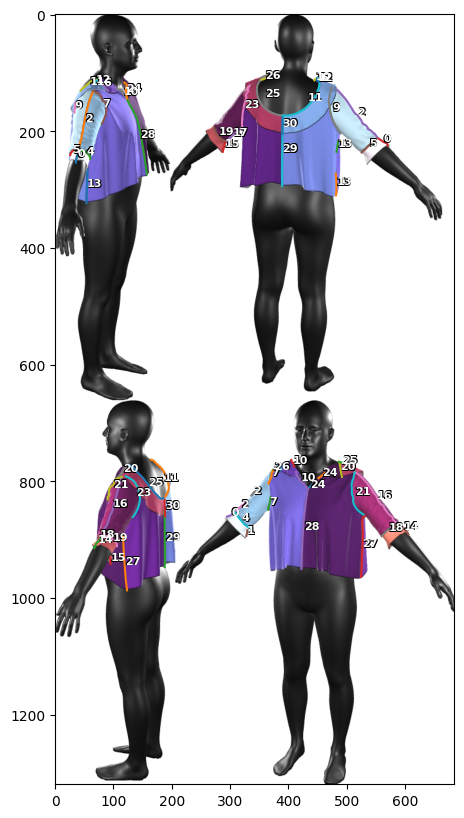

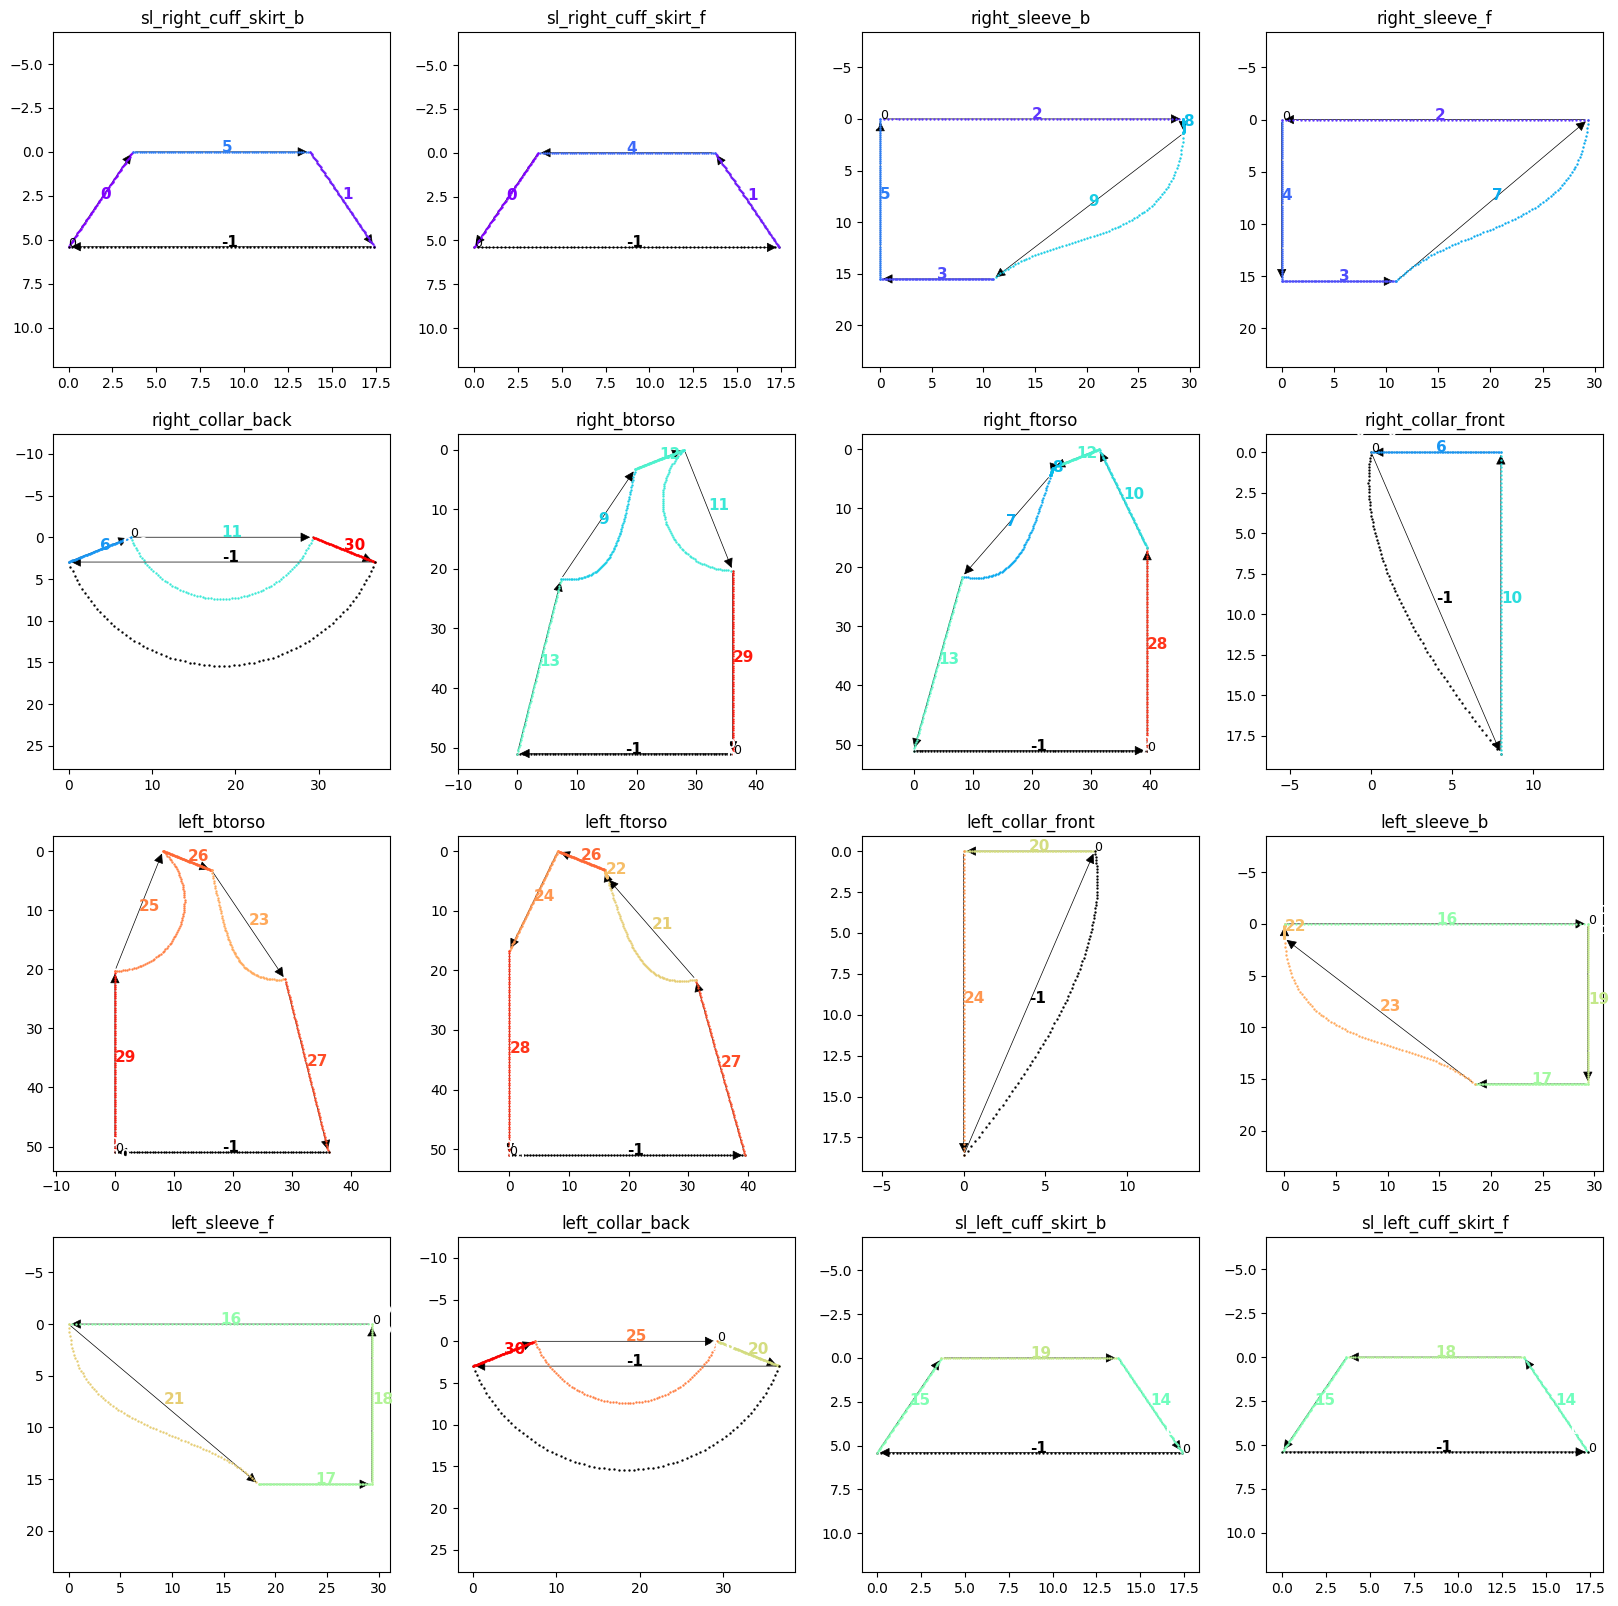

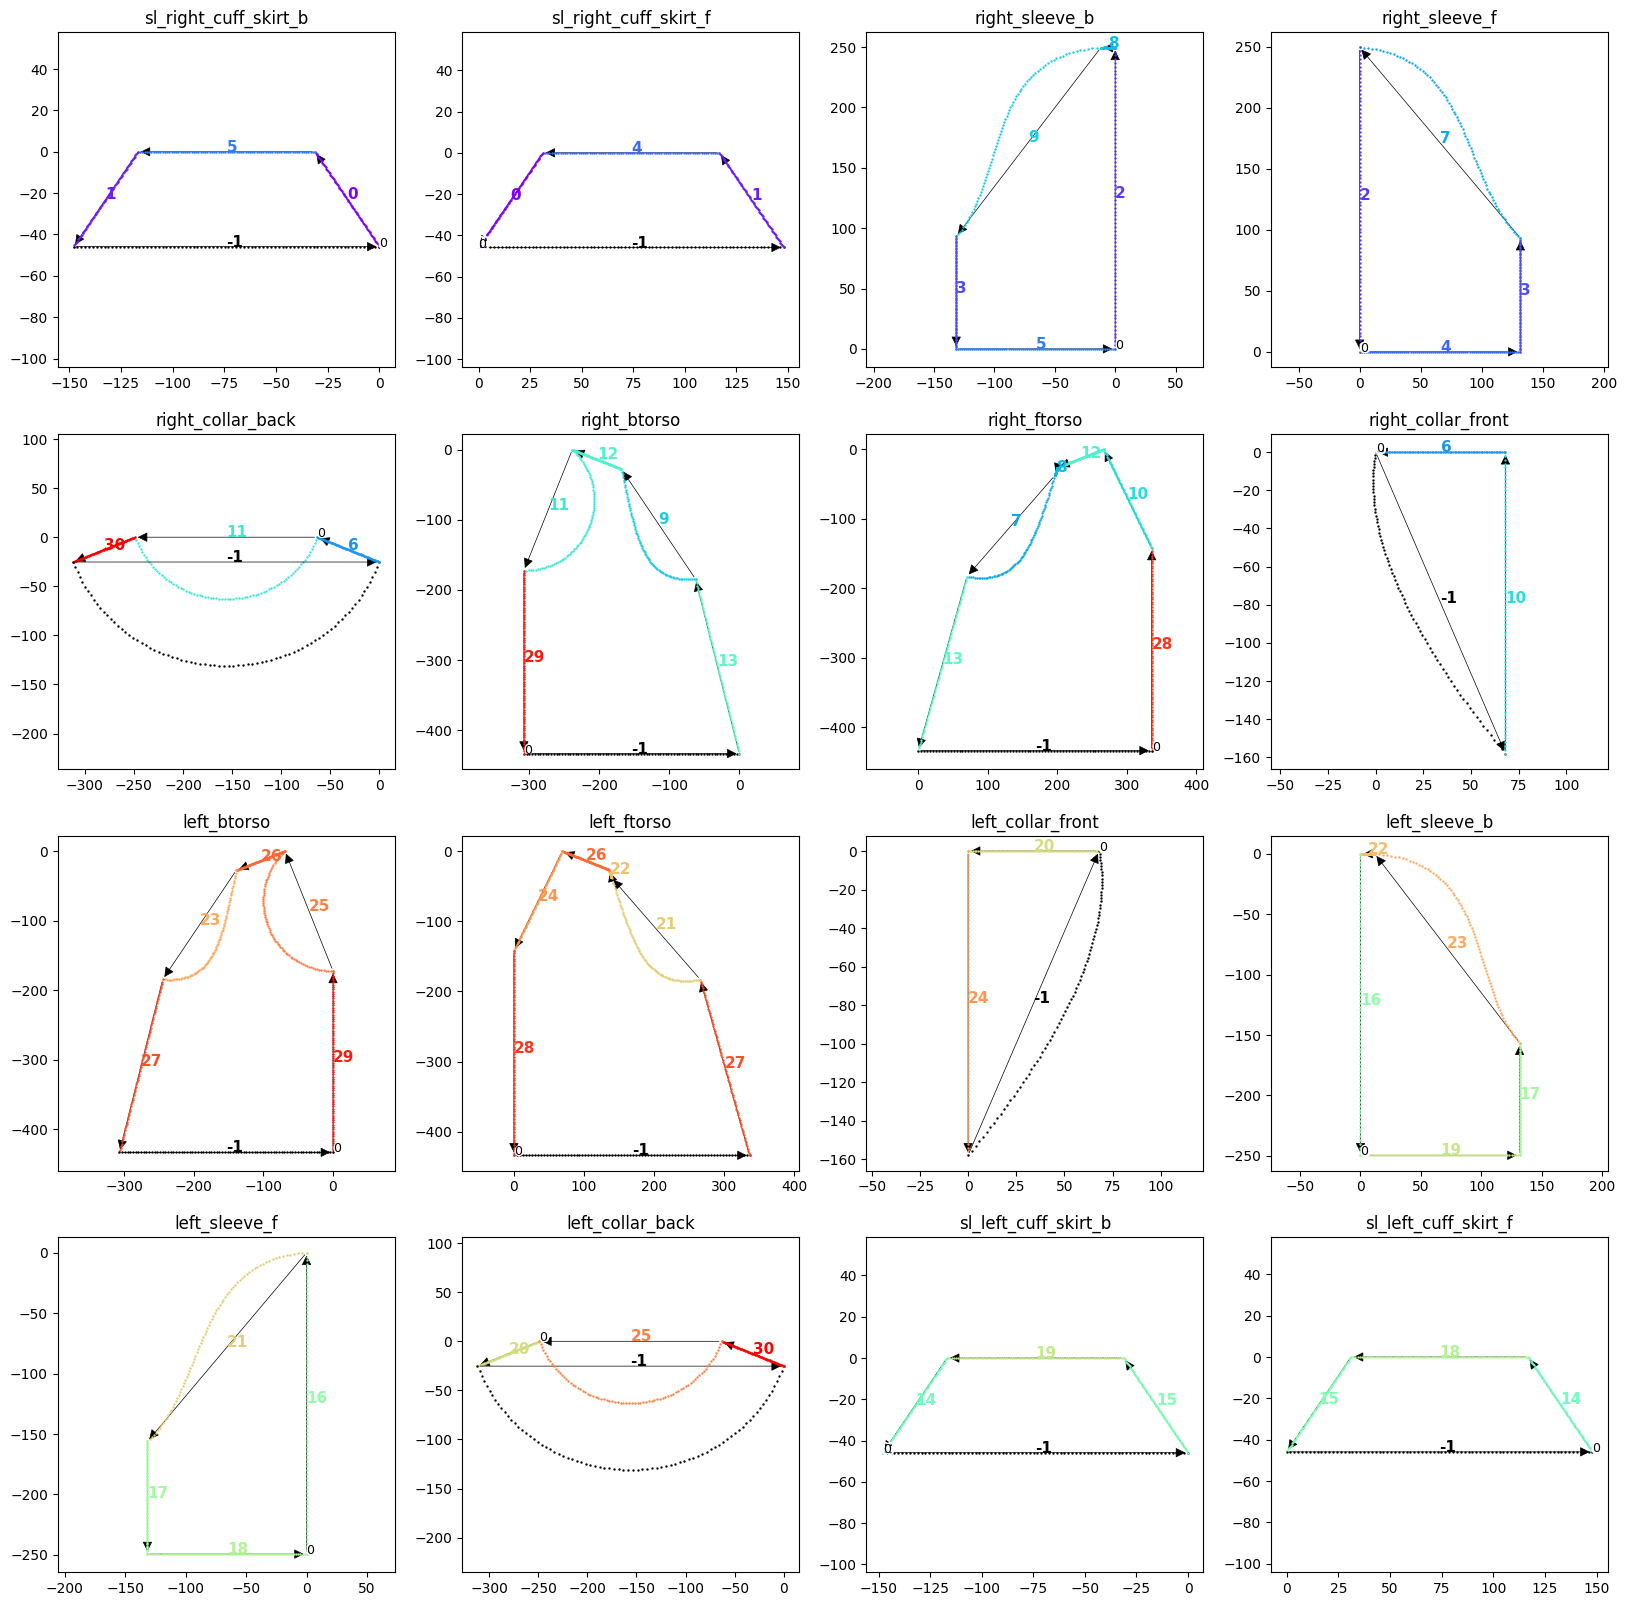

In [57]:
from pathlib import Path
import pandas as pd



panel_name_refine_map = {
    'left_collar_back'      : " collar left back",
    'left_collar_front'     : " collar left front",
    'right_collar_back'     : " collar right back",
    'right_collar_front'    : " collar right front",
    'left_hood'             : " hood left",
    'right_hood'            : " hood right",
    'pant_b_l'              : " pant left back",
    'pant_b_r'              : " pant right back",
    'pant_f_l'              : " pant left front",
    'pant_f_r'              : " pant right front",
    'pant_l_cuff_b'         : " pant cuff left back",
    'pant_l_cuff_f'         : " pant cuff left front",
    'pant_l_cuff_skirt_b'   : " pant cuff skirt left back",
    'pant_l_cuff_skirt_f'   : " pant cuff skirt left front",
    'pant_r_cuff_b'         : " pant cuff right back",
    'pant_r_cuff_f'         : " pant cuff right front",
    'pant_r_cuff_skirt_b'   : " pant cuff skirt right back",
    'pant_r_cuff_skirt_f'   : " pant cuff skirt right front",
    'left_btorso'           : " torso left back",
    'left_ftorso'           : " torso left front",
    'right_btorso'          : " torso right back",
    'right_ftorso'          : " torso right front",
    'left_sleeve_b'         : " sleeve left back",
    'left_sleeve_f'         : " sleeve left front",
    'skirt_back'            : " skirt back",
    'skirt_front'           : " skirt front",
    'right_sleeve_b'        : " sleeve right back",
    'right_sleeve_f'        : " sleeve right front",
    'sl_left_cuff_b'        : " sleeve cuff left back",
    'sl_left_cuff_f'        : " sleeve cuff left front",
    'sl_left_cuff_skirt_b'  : " sleeve cuff skirt left back",
    'sl_left_cuff_skirt_f'  : " sleeve cuff skirt left front",
    'sl_right_cuff_b'       : " sleeve cuff right back",
    'sl_right_cuff_f'       : " sleeve cuff right front",
    'sl_right_cuff_skirt_b' : " sleeve cuff skirt right back",
    'sl_right_cuff_skirt_f' : " sleeve cuff skirt right front",
    'wb_back'               : " waist band back",
    'wb_front'              : " waist band front",
}
side_list = get_poc_dataset_view_name_list()



fabric_uuid_set= set()
fabric_uuid = get_unique_random_string(fabric_uuid_set)
fabric_uuid_set.add(fabric_uuid)
random_hexa_code = generate_random_hex()


# ================================
# IDX = random.randint(0, len(garment_path_list) - 1)
# ================================

print(IDX)
garment_path = os.path.join(
    DATASET_ROOT,
    "GarmentCodeData_v2",
    garment_path_list[IDX]
    # garment_code_data_df["garment_path"].tolist()[IDX]
)
print(garment_path)

garment_split, _, garment_id = list(Path(garment_path).parts)[-3:]

# garment_id = os.path.basename(garment_path)

view_label_dict, sewing_pattern, (box_mesh, panel_vertex_mask_dict) = read_poc_datapoint(
    garment_path, side_list, panel_name_refine_map
)


# < JUST VIS
n_side    = 4 # random.randint(2, 4) 
sampled_side_list = random.sample(side_list, n_side)
combined_label = combine_images_and_labels(
    list(map(lambda x: view_label_dict[x], sampled_side_list)),
    sewing_pattern,
)
plt.figure(figsize=(10, 10))
plt.imshow(combined_label.img)
for seam_line_dict in combined_label.seam_line_dict_list :
    for seam_line_idx, seam_line in seam_line_dict.items() :
        for segment_idx, segment in enumerate(seam_line.segment_vert_pos_arr_list) :
            plt.plot(segment[:, 0],segment[:, 1])
            text_obj = plt.annotate(
                f"{seam_line_idx}",
                (segment[:, 0].mean(), segment[:, 1].mean()),
                fontsize=8, color="white", fontweight="bold"
            )
            for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                plt.annotate(
                    f"{seam_line_idx}",
                    (segment[:, 0].mean() + dx, segment[:, 1].mean() + dy),
                    fontsize=8, fontweight="bold",
                    zorder=text_obj.zorder - 1
                )
plt.show()
# > JUST VIS

panel_center_point_dict = {}
for k in panel_vertex_mask_dict.keys():
    if len(panel_vertex_mask_dict[k]) > 0:  # panel_vertex_mask_dict[k]가 비어 있지 않은지 확인
        panel_center_point_dict[k] = np.mean(box_mesh.vertices[panel_vertex_mask_dict[k]], axis=0)
    else:
        panel_center_point_dict[k] = np.nan  # 빈 배열이면 NaN 또는 다른 적절한 값으로 설정

clo_format_dict = {
    "FabricList": [],
    "GradingRuleTableList": [],
    "PatternList": [],
    "SymmetricDataList": [],
    "InstanceDataList": [],
    "SeamLinePairGroupList": [],
}

sewing_pattern.draw()
plt.show()
 
for panel_name, svg_panel in sewing_pattern.panel_dict.items() :
    svg_panel.approximate_quadratic_bezier_with_cubic_bezier(VIS = False)
    svg_panel.approximate_arc_with_cubic_bezier(VIS = False)
    svg_panel.scale(8.5)
    svg_panel.mirror_vertical()

    if "sleeve" in panel_name :
        if "left" in panel_name :
            sewing_pattern.panel_dict[panel_name].rotate_clockwise(-90)
        if "right" in panel_name :
            sewing_pattern.panel_dict[panel_name].rotate_clockwise(90)
    refined_panel_name = sewing_pattern.panel_name_refine_map[panel_name] if panel_name in panel_name_refine_map else panel_name
    if "back" in refined_panel_name :
        sewing_pattern.mirror_panel_horizontally(panel_name)
    if sewing_pattern.panel_dict[panel_name].is_clockwise() != True :
        sewing_pattern.reverse_panel_path(panel_name)
    
    panel_batch_point = matching_point(
        panel_center_point_dict[panel_name]
    )

    panel_data_json = {
        "Name": f"{garment_id}_{panel_name}", # garment_id 추가함.
        "fGrainlineAngle": 0.0,
        "ID": f"{garment_id}_{panel_name}", # garment_id 추가함.
        "strSuperImposeSide": "None",
        "CurrentFabricUUID": fabric_uuid,
        "IsClosed": False,
        "InternalLineList": [],
        "ButtonHeadList": [],
        "ButtonHoleList": [],
        "AnnotationList": [],
        "NotchList": [],
        "IsHalfSymmetric": False,
        "ShapeInfo": {
            "IsSlashed": False,
            "LineList": [],
            "HalfSymmetryPointIDMap": {},
            "HalfSymmetryLineIDMap": {}
        },
        "ArrangementPointDataMap": {
                "PointName": panel_batch_point,
                "fOffSetX": 0.0,
                "fOffSetY": 0.05,
                "fAngle": 180.0
        }
    }
    # InstanceDataList에 json에 추가
    instance_data = {
        "OriginPatternID": panel_name,  # 패널 이름을 OriginPatternID로 사용
        "InstancePatternIDArray": []   # 빈 리스트로 추가
    }
    
    clo_format_dict["InstanceDataList"].append(instance_data)
    
    coordinate_id_map = {}
    for edge_idx, edge in enumerate(svg_panel.svg_path):
        line_id = f"{panel_name}_edge_{edge_idx}"
        point_list = [] 
        
        if isinstance(edge, svgpath.CubicBezier):
            point_type_list = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
            attribute_list = ["start", "control1", "control2", "end"]
        elif isinstance(edge, svgpath.Line):
            point_type_list = ["Straight", "Straight"]
            attribute_list = ["start", "end"]
        else :
            raise ValueError(f"Unknown edge type: {type(edge)}")
        
        for point_type, attribute in zip(point_type_list, attribute_list) :
            x = round(getattr(edge, attribute).real, 5)
            y = round(getattr(edge, attribute).imag, 5)
            key = (x, y)
            if key not in coordinate_id_map:
                coordinate_id_map[key] = f"{panel_name}_point_{len(coordinate_id_map)}"
            point_id = coordinate_id_map[key]
            point_list.append({
                "ID": point_id, 
                "PointType": point_type,
                "Position": {"x": x, "y": y},
                "GradingRuleID": -1
            })
            
        line = {"ID": line_id, "PointList": point_list}
        panel_data_json["ShapeInfo"]["LineList"].append(line)
                
    clo_format_dict["PatternList"].append(panel_data_json)
sewing_pattern.draw(invert_yaxis=False)
plt.show()



clo_format_dict["SeamLinePairGroupList"] = []
fabric_group = {
    "FabricName" : "Default Fabric",
    "FabricType" : "None",
    "FabricContent" : "None",
    "strBaseColorHexCode" : random_hexa_code,
    "FabricUUID" : fabric_uuid
    }
# SeamLinePairGroupList 생성 루프

for stch_idx, stch_info in sewing_pattern.stitch_dict.items() :
# for idx, value in enumerate(stitch_dict.values()):
    # "Name" 생성
    group_name = f"{garment_id}_SeamLineGroup_{stch_idx}"

    # 정보 저장
    first_panel = stch_info.panel_0
    first_edge  = stch_info.edge_0
    first_shape_id = f"{garment_id}_{first_panel}"
    fstt = sewing_pattern.panel_dict[first_panel].normalized_edge_stt(first_edge)
    fend = sewing_pattern.panel_dict[first_panel].normalized_edge_end(first_edge)
    
    second_panel = stch_info.panel_1
    second_edge = stch_info.edge_1 
    second_shape_id = f"{garment_id}_{second_panel}"
    sstt = sewing_pattern.panel_dict[second_panel].normalized_edge_stt(second_edge)
    send = sewing_pattern.panel_dict[second_panel].normalized_edge_end(second_edge)
    
    first_direction = True
    second_direction = False
    
    # direction 결정 뒤에 정해 놓는 fstart, fend
    if first_direction == False:
        first_fstart, first_fend = fend, fstt
    else:
        first_fstart, first_fend = fstt, fend        
        
    if second_direction == False:
        second_fstart, second_fend = send, sstt
    else:
        second_fstart, second_fend = sstt, send
    

    # JSON 구조 생성
    seam_line_pair_group = {
        "Name": group_name,
        "bIsTurned": False,
        "PairList": [
            {
                "First": {
                    "ShapeID": first_shape_id,
                    "LengthParam": {
                        "fStart": first_fstart,
                        "fEnd": first_fend
                    },
                    "Direction": first_direction
                },
                "Second": {
                    "ShapeID": second_shape_id,
                    "LengthParam": {
                        "fStart": second_fstart,
                        "fEnd": second_fend
                    },
                    "Direction": second_direction 
                }
            }
        ],
        "FoldData": {
            "iAngle": 180,
            "iStrength": 5
        }
    }

    # SeamLinePairGroupList에 추가
    clo_format_dict["SeamLinePairGroupList"].append(seam_line_pair_group)

clo_format_dict["FabricList"].append(fabric_group)    


SAVE_PATH = Path(os.path.join(
    CLO_DATASET_ROOT, "GarmentCodeData_v2", garment_split, garment_id,
    f"{garment_id}_config.json"
))
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(str(SAVE_PATH), "w") as fp :
    json.dump(clo_format_dict, fp, indent=4)
